# Zimbabwe (2017) — GEE fire EDA v1

**Purpose:** Same *exploration* style as [`zambia_gee_v3.ipynb`](zambia_gee_v3.ipynb): MODIS **MCD64A1** burned area and **FIRMS** hot-pixel area proxy, summarized to **GADM 4.0 admin‑2** (`ID_1` / `ID_2` pcodes) for **Zimbabwe**.

**Survey timing:** Parsed from **`VACS_survey_time.csv`** (resolved via `utils.vacs_survey_time.resolve_vacs_survey_time_csv`: prefers `data/raw/`, else `skills/`). Row **Zimbabwe (2017)** — `date_parse_flag` must be **`range_ok`** before this notebook uses the dates.

**Exposure window (v0, same rule as Zambia v3):** inclusive **12 calendar months** ending the day **before** the first fieldwork day (`field_start − 1 day`), starting the same calendar month/day one year earlier (`field_start` minus one year). *If the PI wants a different definition (e.g. anchored on last field day), change the helper or constants after confirming.*

**Boundaries:** Local **GADM 4.0** GeoJSON via **`utils.gadm_boundaries`** (`data/raw/gadm/4.0/`). Zambia notebooks still use FAO GAUL 2015 — see [`gee_zambia/GEE_country_scope.md`](../gee_zambia/GEE_country_scope.md).

**Reuse:** `utils/gee_fire_zonal.py`, `utils/gadm_boundaries.py`, `utils/adam_modis_export.py`, `utils/vacs_survey_time.py`.



## Catalog — fire-related layers in EE (relevant to 2017)

| Earth Engine ID | Product | Notes |
|-------------------|---------|--------|
| `MODIS/061/MCD64A1` | MODIS burned area (v6.1), monthly | `BurnDate` > 0 in month window |
| `FIRMS` | MODIS active fire, ~1 km | `T21` threshold proxy (v0 default 325 K) |
| `NASA/VIIRS/002/VNP14A1` | VIIRS SNPP L3 thermal / fire | Daily since 2012 — optional next step |

Same conceptual setup as Zambia v3; only the **country filter** and **calendar** change.


## §1 — Repo root, `.env`, survey + exposure calendar

Loads **`VACS_survey_time.csv`**, parses Zimbabwe 2017 field dates, builds **`months_df`** for EE `Filter.date`, and sets **`DEMO_MONTH_*`** to the **first exposure month** (override manually to probe another month).



In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

_repo = next(
    (
        d
        for d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (d / "utils" / "repo_paths.py").is_file() and (d / "data" / "raw").is_dir()
    ),
    None,
)
if _repo is None:
    raise RuntimeError("Cannot find repo root (expected utils/repo_paths.py and data/raw/).")
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))
from utils.repo_paths import find_repo_root
from utils.vacs_survey_time import (
    add_parsed_field_dates,
    exposure_window_inclusive_before_field_start,
    field_dates_as_python_dates,
    get_country_wave_row,
    load_survey_time_table,
    months_df_inclusive_range,
    resolve_vacs_survey_time_csv,
)

ROOT = find_repo_root()
try:
    from dotenv import load_dotenv

    load_dotenv(ROOT / ".env", override=False)
except ImportError:
    pass

COUNTRY_WAVE = "Zimbabwe (2017)"
ADM0_NAME = "Zimbabwe"
GADM_ISO3 = "ZWE"  # GADM ID_0 (not GAUL ADM0_NAME)
GADM_VERSION = "40"

survey_path = resolve_vacs_survey_time_csv(ROOT)
survey_raw = load_survey_time_table(survey_path)
survey_parsed = add_parsed_field_dates(survey_raw)
row = get_country_wave_row(survey_parsed, COUNTRY_WAVE)
if row["date_parse_flag"] != "range_ok":
    raise RuntimeError(
        f"Refusing to use dates: {COUNTRY_WAVE!r} has date_parse_flag={row['date_parse_flag']!r} "
        "(fix CSV or parsing before GEE pulls)."
    )

SURVEY_FIELD_START, SURVEY_FIELD_END = field_dates_as_python_dates(row)
EXPOSURE_START, EXPOSURE_END = exposure_window_inclusive_before_field_start(
    SURVEY_FIELD_START, years_before=1
)
months_df = months_df_inclusive_range(EXPOSURE_START, EXPOSURE_END)

# Default demo month = first row of exposure calendar (change to probe another month)
DEMO_MONTH_START = months_df.loc[0, "month_start"].isoformat()
DEMO_MONTH_END_EXCLUSIVE = months_df.loc[0, "filter_end_exclusive"].isoformat()

print("ROOT =", ROOT)
print("exposure window (12 mo pre-field):", EXPOSURE_START, "..", EXPOSURE_END, "| n_months =", len(months_df))
print("DEMO_MONTH", DEMO_MONTH_START, "->", DEMO_MONTH_END_EXCLUSIVE)



ROOT = /Users/starsrain/research_side_projects_ipv
exposure window (12 mo pre-field): 2016-01-01 .. 2016-12-31 | n_months = 12
DEMO_MONTH 2016-01-01 -> 2016-02-01


## §2 — Earth Engine session

Requires `earthengine authenticate` and **`EARTHENGINE_PROJECT`** (or default in cell).


In [2]:
import ee

from utils.gee_fire_zonal import ee_initialize_from_environ

EE_PROJECT = ee_initialize_from_environ()
print("OK", EE_PROJECT)



OK ipv-exposure-research


## §3 — Admin‑2 regions (GADM 4.0)

Uses **`utils.gadm_boundaries.gadm_level2_feature_collection`** (local GeoJSON under `data/raw/gadm/4.0/`). **60** districts for Zimbabwe; `adm*_pcode` in exports use GADM **`ID_1`** / **`ID_2`** (teammate `ISO_1` / `ISO_2`).


In [3]:
from utils.gadm_boundaries import gadm_geojson_path, gadm_level2_feature_collection

regions = gadm_level2_feature_collection(GADM_ISO3, version=GADM_VERSION)
gadm_path = gadm_geojson_path(GADM_ISO3, 2, version=GADM_VERSION)
print("n_features", regions.size().getInfo(), "GADM ADM2", gadm_path)
print(
    "sample pcode",
    regions.first().getInfo()["properties"]["ADM2_CODE"],
    regions.first().getInfo()["properties"]["ADM2_NAME"],
)



n_features 60 GADM ADM2 /Users/starsrain/research_side_projects_ipv/data/raw/gadm/4.0/gadm40_ZWE_2.json
sample pcode ZWE.1.1_1 Bulawayo


## §4 — MODIS burned area (MCD64A1) → `burn_area_ha` per district

**Definition (v0):** same as Zambia v3 — max monthly `BurnDate` > 0, × pixel area, sum per polygon, ÷ 10 000 → ha. Scale **500** m (native-ish for MCD64).

**Display:** the code cell prints the **national month total** (sum of district `burn_area_ha`); the table is a **two-row snapshot** (max burn this month + first district alphabetically). Inspect `burn_df` for all rows.


In [4]:
from utils.gee_fire_zonal import mcd64a1_burn_area_m2_image, reduce_sum_m2_per_feature_to_df

burn_m2 = mcd64a1_burn_area_m2_image(DEMO_MONTH_START, DEMO_MONTH_END_EXCLUSIVE)
burn_df = reduce_sum_m2_per_feature_to_df(
    burn_m2,
    regions,
    band_name="burn_area_m2",
    out_ha_column="burn_area_ha",
    scale_m=500.0,
)
print("month", DEMO_MONTH_START[:7], "total burn ha (sum districts)", burn_df["burn_area_ha"].sum())
print("districts (rows)", len(burn_df))
burn_tbl = burn_df[["ADM1_NAME", "ADM2_NAME", "burn_area_ha"]].sort_values(
    ["ADM1_NAME", "ADM2_NAME"]
).reset_index(drop=True)
cols3 = ["ADM1_NAME", "ADM2_NAME", "burn_area_ha"]
snap_burn = pd.concat(
    [
        burn_df.nlargest(1, "burn_area_ha")[cols3],
        burn_tbl.head(1)[cols3],
    ]
).drop_duplicates()
display(snap_burn)
print("snapshot rows (max burn this month + first ADM1/ADM2 alphabetically); full table", len(burn_tbl), "rows")



month 2016-01 total burn ha (sum districts) 700.9795984375
districts (rows) 60


,ADM1_NAME,ADM2_NAME,burn_area_ha
46,MatabelelandSouth,Bulilima(North),536.137933
0,Bulawayo,Bulawayo,0.000000


snapshot rows (max burn this month + first ADM1/ADM2 alphabetically); full table 60 rows


## §4b — National burn total: month-over-month % change (2016 exposure year)

For each row in **`months_df`**, rerun the §4 MCD64 stack and sum **`burn_area_ha`** over all GADM admin‑2 polygons (national total). **MoM %** = \((T_t - T_{t-1}) / T_{t-1} \times 100\); undefined when the previous month total is **0** (shown as a gap in the line). **Jan→Dec %** compares first and last month totals in the same way (informational; not “annual” in a fiscal sense).

**Figure:** **bars** = national total burn (ha) each month; **orange line** = MoM % on a **secondary axis** (large swings when the prior month is near zero are expected).

**Caveat:** this is **MODIS MCD64A1 v0 mask** totals at **500 m** scale—good for internal EDA, not a substitute for PI‑signed exposure definitions.


National MODIS burn (ha), sum districts — first month: 700.9795984375 last month: 213.6282984375
Relative change first→last month in window (%): -69.52432012091614


,month_label,total_burn_ha,mom_pct
0,2016-01,700.979598,NaN
1,2016-02,47.064801,-93.285853
2,2016-03,23.710111,-49.622413
3,2016-04,935.105734,3843.911257
4,2016-05,5451.648603,482.998093
5,2016-06,67594.693858,1139.894549
6,2016-07,182499.785920,169.991290
7,2016-08,478524.906604,162.205736
8,2016-09,766047.026791,60.085090
9,2016-10,597080.801971,-22.056900


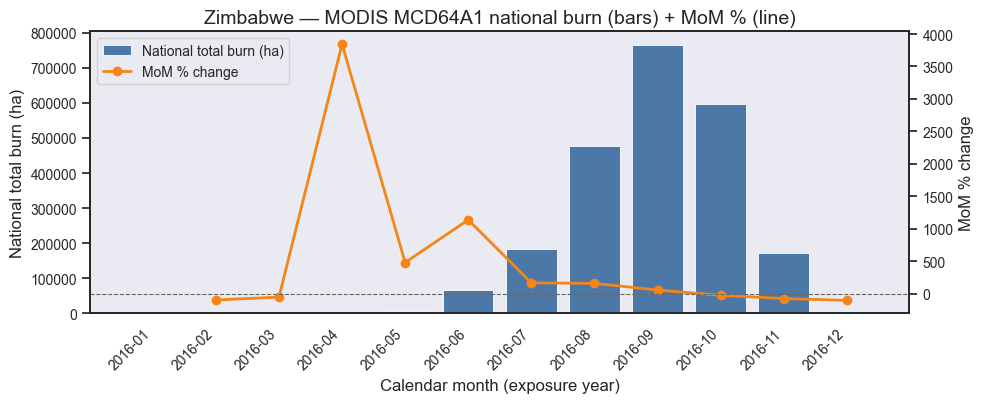

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from utils.gee_fire_zonal import mcd64a1_burn_area_m2_image, reduce_sum_m2_per_feature_to_df
from utils.plot_style import ACCENT_COLOR, PRIMARY_COLOR, apply_plot_style


def _iso(d) -> str:
    if hasattr(d, "isoformat"):
        return d.isoformat()
    return str(d)[:10]


burn_rows: list[dict] = []
for _, mr in months_df.iterrows():
    ms = _iso(mr["month_start"])
    mex = _iso(mr["filter_end_exclusive"])
    burn_m2_m = mcd64a1_burn_area_m2_image(ms, mex)
    bdf_m = reduce_sum_m2_per_feature_to_df(
        burn_m2_m,
        regions,
        band_name="burn_area_m2",
        out_ha_column="burn_area_ha",
        scale_m=500.0,
    )
    burn_rows.append(
        {
            "month_start": pd.Timestamp(mr["month_start"]),
            "total_burn_ha": float(bdf_m["burn_area_ha"].sum()),
        }
    )

burn_monthly = pd.DataFrame(burn_rows).sort_values("month_start").reset_index(drop=True)
burn_monthly["mom_pct"] = burn_monthly["total_burn_ha"].pct_change() * 100.0

first_ha = burn_monthly.iloc[0]["total_burn_ha"]
last_ha = burn_monthly.iloc[-1]["total_burn_ha"]
if first_ha > 0:
    first_to_last_pct = (last_ha - first_ha) / first_ha * 100.0
else:
    first_to_last_pct = float("nan")

print("National MODIS burn (ha), sum districts — first month:", first_ha, "last month:", last_ha)
print("Relative change first→last month in window (%):", first_to_last_pct)
display(
    burn_monthly.assign(month_label=lambda d: d["month_start"].dt.strftime("%Y-%m"))[
        ["month_label", "total_burn_ha", "mom_pct"]
    ]
)

apply_plot_style(style="white", axes_grid=False)

labels = burn_monthly["month_start"].dt.strftime("%Y-%m")
x = list(range(len(burn_monthly)))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(
    x,
    burn_monthly["total_burn_ha"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    linewidth=0.6,
    label="National total burn (ha)",
)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("National total burn (ha)")
ax.set_xlabel("Calendar month (exposure year)")

ax2 = ax.twinx()
ax2.plot(
    x,
    burn_monthly["mom_pct"],
    color=ACCENT_COLOR,
    marker="o",
    linewidth=2,
    label="MoM % change",
)
ax2.axhline(0.0, color="#666666", linewidth=0.8, linestyle="--")
ax2.set_ylabel("MoM % change")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
ax.set_title("Zimbabwe — MODIS MCD64A1 national burn (bars) + MoM % (line)")
fig.tight_layout()
plt.show()


## §5 — FIRMS hot-pixel area proxy → `hot_area_ha`

**Definition (v0):** max `T21` over the month, > **325 K**, × pixel area; scale **1000** m (FIRMS grid step in EE docs).

**Display:** same snapshot pattern as §4; inspect `firms_df` for the full district table.


In [7]:
from utils.gee_fire_zonal import firms_hot_area_m2_image, reduce_sum_m2_per_feature_to_df

hot_m2 = firms_hot_area_m2_image(DEMO_MONTH_START, DEMO_MONTH_END_EXCLUSIVE)
firms_df = reduce_sum_m2_per_feature_to_df(
    hot_m2,
    regions,
    band_name="hot_area_m2",
    out_ha_column="hot_area_ha",
    scale_m=1000.0,
)
print("month", DEMO_MONTH_START[:7], "total hot-area proxy ha", firms_df["hot_area_ha"].sum())
print("districts (rows)", len(firms_df))
firms_tbl = firms_df[["ADM1_NAME", "ADM2_NAME", "hot_area_ha"]].sort_values(
    ["ADM1_NAME", "ADM2_NAME"]
).reset_index(drop=True)
cols3h = ["ADM1_NAME", "ADM2_NAME", "hot_area_ha"]
snap_hot = pd.concat(
    [
        firms_df.nlargest(1, "hot_area_ha")[cols3h],
        firms_tbl.head(1)[cols3h],
    ]
).drop_duplicates()
display(snap_hot)
print("snapshot rows (max hot-area proxy this month + first ADM1/ADM2 alphabetically); full table", len(firms_tbl), "rows")



month 2016-01 total hot-area proxy ha 13062.50270769608
districts (rows) 60


,ADM1_NAME,ADM2_NAME,hot_area_ha
38,MatabelelandNorth,Binga,2938.201150
0,Bulawayo,Bulawayo,673.163259


snapshot rows (max hot-area proxy this month + first ADM1/ADM2 alphabetically); full table 60 rows


## §6 — Adam-format MODIS export (admin-2, monthly + rolling 12)

Matches **`skills/Adam_Modis.docx`** / **`skills/Adam_kenya_modis_2010.csv`** column layout, plus our **`burn_area_ha`** and **`mom_pct_change`**.

- **`monthly_burned_area_km2`**: Adam MODIS sum (burned pixels × area, km²) per district per month  
- **`rolling12_burned_area_avg_km2`**: mean of the prior **12** monthly district totals (same window rule as Adam's EE)  
- **`adm*_pcode`**: `ZW` + GADM **`ID_1`** / **`ID_2`** (same as teammate `ISO_1` / `ISO_2` in `skills/GADM_admin_areas_v1.xlsx`)  
- **Boundaries:** GADM **4.0** polygons (`data/raw/gadm/4.0/`); burn months **2016** (exposure window).  
- **CSV rows:** exposure window only (**12** months before fieldwork). GEE still pulls **11 extra history months** internally so **rolling12** is defined for the first exposure month — history months are **not** in the CSV.


In [8]:
from pathlib import Path

from utils.adam_modis_export import (
    build_adam_modis_export,
    months_table_for_rolling,
    write_adam_modis_csv,
)

ADM0_PCODE = "ZW"  # ISO3; Adam Kenya uses "KE"

months_gee = months_table_for_rolling(
    EXPOSURE_START,
    EXPOSURE_END,
    history_months=11,
)
print("GEE pulls:", len(months_gee), "months (extra history for rolling only; CSV keeps exposure window)")

adam_zwe = build_adam_modis_export(
    months_gee,
    regions,
    adm0_name=ADM0_NAME,
    adm0_pcode=ADM0_PCODE,
    exposure_start=EXPOSURE_START,
    exposure_end=EXPOSURE_END,
    scale_m=500.0,
)

OUT_CSV = ROOT / "data" / "processed" / "zimbabwe_modis_mcd64_gadm40_2016.csv"
write_adam_modis_csv(adam_zwe, OUT_CSV)
print("Wrote", OUT_CSV)
print("rows", len(adam_zwe), "districts", adam_zwe["adm2_name"].nunique(), "months", adam_zwe["month_start"].nunique())
display(adam_zwe.head(8))


GEE pulls: 23 months (extra history for rolling only; CSV keeps exposure window)
Wrote /Users/starsrain/research_side_projects_ipv/data/processed/zimbabwe_modis_mcd64_gadm40_2016.csv
rows 720 districts 60 months 12


,adm0_name,adm0_pcode,adm1_name,adm1_pcode,adm2_name,adm2_pcode,month_start,month_end,rolling_start,rolling_end,monthly_burned_area_km2,rolling12_burned_area_avg_km2,burn_area_ha,mom_pct_change
660,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-01-01,2016-02-01,2015-02-01,2016-02-01,0.0,2.781861,0.0,NaN
720,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-02-01,2016-03-01,2015-03-01,2016-03-01,0.0,2.781861,0.0,NaN
780,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-03-01,2016-04-01,2015-04-01,2016-04-01,0.0,2.781861,0.0,NaN
840,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-04-01,2016-05-01,2015-05-01,2016-05-01,0.0,2.781861,0.0,NaN
900,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-05-01,2016-06-01,2015-06-01,2016-06-01,0.0,2.781861,0.0,NaN
960,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-06-01,2016-07-01,2015-07-01,2016-07-01,0.0,2.536791,0.0,NaN
1020,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-07-01,2016-08-01,2015-08-01,2016-08-01,0.0,1.968427,0.0,NaN
1080,Zimbabwe,ZW,Bulawayo,ZWE.1_1,Bulawayo,ZWE.1.1_1,2016-08-01,2016-09-01,2015-09-01,2016-09-01,0.0,1.298651,0.0,NaN
